<a href="https://colab.research.google.com/github/07Supreme/AI/blob/main/2438440_SupremeMaharjan_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Choose, Load and Inspect your Data

(a) How did you access the dataset?
ans: I got acess to this dataset from the website kaggle.com.

(b) How does it align with the chosen UNSDG?
ans: This dataset aligns with UN Sustainable Development Goal (UNSDG) 3: Good Health and Well-being, as it focuses on heart disease prediction, which can help improve early diagnosis, preventive measures, and healthcare decision-making.

(c) List all the attributes (columns) present in the dataset.
ans: Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS, RestingECG,    MaxHR, ExerciseAngina, Oldpeak, ST_Slope, HeartDisease

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:

df = pd.read_csv("/content/drive/MyDrive/Ai/Final Assignment/Classification/heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [ ]:
df.dtypes


,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [ ]:
df.isnull().any()

,0
Age,False
Sex,False
ChestPainType,False
RestingBP,False
Cholesterol,False
FastingBS,False
RestingECG,False
MaxHR,False
ExerciseAngina,False
Oldpeak,False


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


EXPLORATORY DATA ANALYSIS


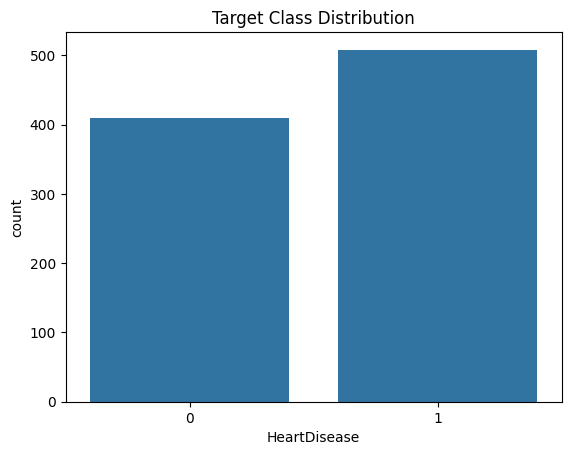

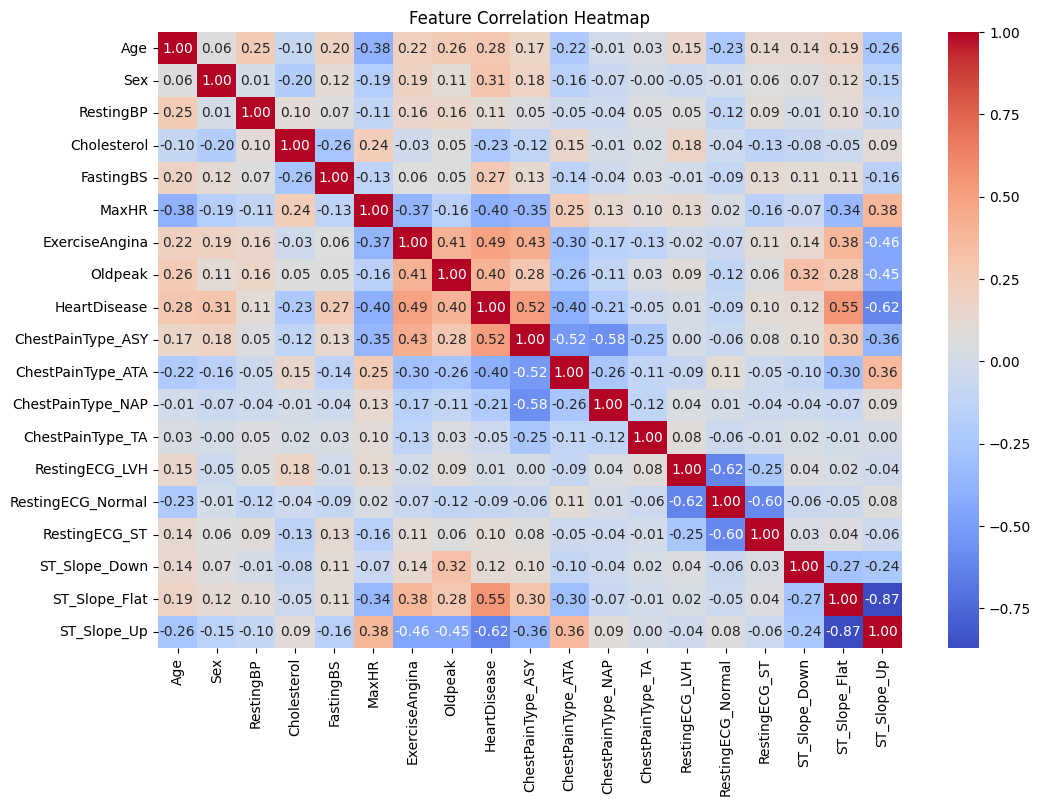

In [ ]:
# Visualizing Target Distribution
sns.countplot(x=df["HeartDisease"])
plt.title("Target Class Distribution")
plt.show()

# Convert 'Sex' column to numeric (0 for Female, 1 for Male)
df['Sex'] = df['Sex'].map({'F': 0, 'M': 1})

# Convert 'ChestPainType' to numeric using one-hot encoding
chest_pain_dummies = pd.get_dummies(df['ChestPainType'], prefix='ChestPainType')
df = pd.concat([df, chest_pain_dummies], axis=1)
df = df.drop('ChestPainType', axis=1)

# Convert 'RestingECG' to numeric using one-hot encoding
resting_ecg_dummies = pd.get_dummies(df['RestingECG'], prefix='RestingECG')
df = pd.concat([df, resting_ecg_dummies], axis=1)
df = df.drop('RestingECG', axis=1)

# Convert 'ExerciseAngina' to numeric (0 for N, 1 for Y)
df['ExerciseAngina'] = df['ExerciseAngina'].map({'N': 0, 'Y': 1})

# Convert 'ST_Slope' to numeric using one-hot encoding
st_slope_dummies = pd.get_dummies(df['ST_Slope'], prefix='ST_Slope')
df = pd.concat([df, st_slope_dummies], axis=1)
df = df.drop('ST_Slope', axis=1)


# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


This code prepares the heart.csv dataset for machine learning by first visualizing the distribution of the target variable (HeartDisease). It then converts categorical columns into numerical values: 'Sex' is mapped to 0 (Female) and 1 (Male), while 'ChestPainType', 'RestingECG', and 'ST_Slope' are transformed using one-hot encoding (creating separate binary columns for each category). 'ExerciseAngina' is mapped to 0 (No) and 1 (Yes). Finally, a correlation heatmap is generated to analyze relationships between features, helping identify patterns and potential predictors for heart disease.

DATA PREPROCESSING


In [ ]:
# Selecting features and target
X = df.drop(columns=["HeartDisease"]).values
y = df["HeartDisease"].values

# Splitting dataset into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardizing the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


LOGISTIC REGRESSION FROM SCRATCH

In [ ]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Logistic Regression training function (Gradient Descent)
def train_logistic_regression(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape
    weights = np.zeros(n)
    bias = 0

    for _ in range(epochs):
        linear_model = np.dot(X, weights) + bias
        predictions = sigmoid(linear_model)

        # Compute gradients
        dw = (1 / m) * np.dot(X.T, (predictions - y))
        db = (1 / m) * np.sum(predictions - y)

        # Update weights
        weights -= learning_rate * dw
        bias -= learning_rate * db

    return weights, bias

# Train logistic regression from scratch
weights_scratch, bias_scratch = train_logistic_regression(X_train_scaled, y_train)

# Predict function
def predict_logistic_regression(X, weights, bias):
    linear_model = np.dot(X, weights) + bias
    return (sigmoid(linear_model) >= 0.5).astype(int)

# Predictions
y_pred_scratch = predict_logistic_regression(X_test_scaled, weights_scratch, bias_scratch)

# Evaluate
acc_scratch = accuracy_score(y_test, y_pred_scratch)
print("\nLogistic Regression from Scratch Accuracy:", acc_scratch)


Logistic Regression from Scratch Accuracy: 0.9021739130434783


TRAIN TWO CLASSIFICATION MODELS

In [ ]:
# Model 1: Logistic Regression (Scikit-learn)
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Model 2: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate models
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("\nModel Performance Comparison:")
print(f"Logistic Regression - Accuracy: {acc_lr:.4f}")
print(f"Random Forest - Accuracy: {acc_rf:.4f}")

# Determine best model
best_model = "Random Forest" if acc_rf > acc_lr else "Logistic Regression"
print(f"\nBest Performing Model: {best_model}")



Model Performance Comparison:
Logistic Regression - Accuracy: 0.8859
Random Forest - Accuracy: 0.8750

Best Performing Model: Logistic Regression


HYPERPARAMETER OPTIMIZATION

In [ ]:
# Hyperparameter tuning for Logistic Regression
lr_params = {"C": [0.01, 0.1, 1, 10, 100]}
lr_cv = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, scoring="accuracy", cv=5)
lr_cv.fit(X_train_scaled, y_train)

best_lr_C = lr_cv.best_params_["C"]
print(f"\nBest Hyperparameter for Logistic Regression: C={best_lr_C}")

# Hyperparameter tuning for Random Forest
rf_params = {"n_estimators": [50, 100, 200], "max_depth": [5, 10, None]}
rf_cv = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, scoring="accuracy", cv=5)
rf_cv.fit(X_train_scaled, y_train)

best_rf_params = rf_cv.best_params_
print(f"Best Hyperparameters for Random Forest: {best_rf_params}")


Best Hyperparameter for Logistic Regression: C=10
Best Hyperparameters for Random Forest: {'max_depth': 10, 'n_estimators': 200}


FEATURE SELECTION

In [ ]:
# Feature selection using Logistic Regression
selector = SelectFromModel(LogisticRegression(C=best_lr_C, max_iter=1000))
selector.fit(X_train_scaled, y_train)

selected_features_mask = selector.get_support()
selected_features = np.array(df.drop(columns=["HeartDisease"]).columns)[selected_features_mask]

print(f"\nSelected Features for the Final Model: {selected_features}")


Selected Features for the Final Model: ['Sex' 'Cholesterol' 'FastingBS' 'ExerciseAngina' 'ChestPainType_ASY'
 'ChestPainType_NAP' 'ST_Slope_Flat' 'ST_Slope_Up']


FINAL MODEL


Final Model Performance:
Final Model Accuracy: 0.8587

Final Model Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.83        82
           1       0.85      0.91      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184



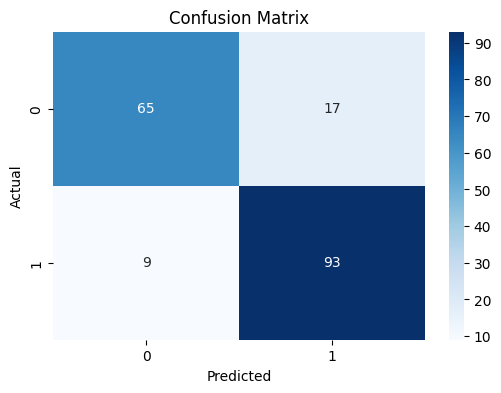

In [ ]:
# Final model uses Logistic Regression
final_model = LogisticRegression(C=best_lr_C, max_iter=1000)

# Train final model with selected features
X_train_final = X_train_scaled[:, selected_features_mask]
X_test_final = X_test_scaled[:, selected_features_mask]

final_model.fit(X_train_final, y_train)
y_pred_final = final_model.predict(X_test_final)

# Evaluate final model
acc_final = accuracy_score(y_test, y_pred_final)
print("\nFinal Model Performance:")
print(f"Final Model Accuracy: {acc_final:.4f}")

# Classification Report
print("\nFinal Model Classification Report:\n", classification_report(y_test, y_pred_final))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

This code trains and evaluates the final Logistic Regression model for heart disease prediction. It uses the best hyperparameter (C=best_lr_C) and selected features for training. After fitting the model, it makes predictions on the test data. The model's performance is assessed using accuracy, a classification report (showing precision, recall, and F1-score), and a confusion matrix, which visualizes how well the model classifies heart disease cases. The results help understand the model's effectiveness in distinguishing between healthy individuals and those with heart disease.